In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, coint
import datetime
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Download data for multivariate time series analysis
print("Downloading market data...")
var_tickers = ['SPY', 'QQQ', 'IWM', 'GLD', 'USO']
var_data = yf.download(var_tickers, start='2016-01-01', end='2025-12-31', progress=False, auto_adjust=False)
var_prices = var_data['Adj Close'].dropna()

# Calculate log returns
var_returns = np.log(var_prices / var_prices.shift(1)).dropna() * 100

print(f"Sample period: {var_returns.index[0].date()} to {var_returns.index[-1].date()}")
print(f"Number of observations: {len(var_returns)}")
print(f"\nAssets: {list(var_returns.columns)}")

Sample period: 2016-01-05 to 2025-12-30
Number of observations: 2512

Assets: ['GLD', 'IWM', 'QQQ', 'SPY', 'USO']


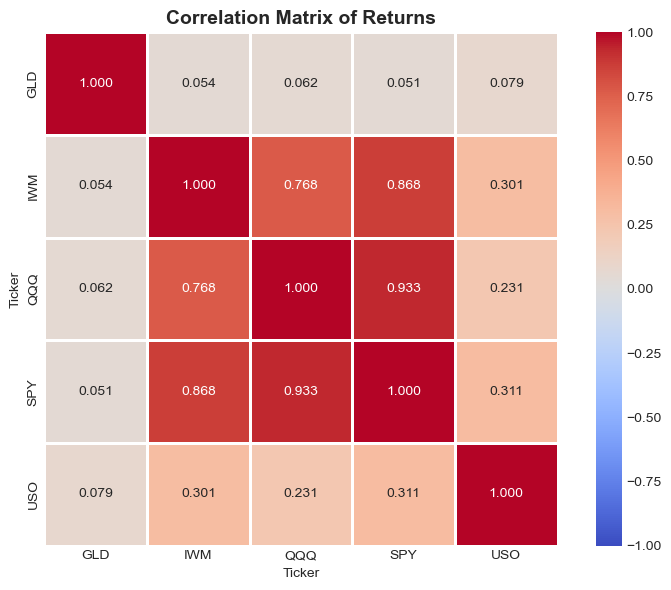

In [4]:
# Correlation
corr_matrix = var_returns.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Correlation Matrix of Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Stationarity test (ADF)

adf_results = {}
for col in var_returns.columns:
    result = adfuller(var_returns[col].dropna(), maxlag=20, regression='c')
    adf_results[col] = {
        'statistic': result[0],
        'p-value': result[1],
        'lags': result[2],
        'critical_values': result[4]
    }
    
    print(f"\n{col}:")
    print(f"- ADF Statistic: {result[0]:.4f}")
    print(f"- p-value: {result[1]:.4f}")
    print(f"- Critical values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")

    if result[1] < 0.05:
        print(f'=> Stationary at 5% significance level')
    else:
        print(f'=> Non-stationary (may need differencing)')
        


GLD:
- ADF Statistic: -50.0277
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

IWM:
- ADF Statistic: -16.3607
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

QQQ:
- ADF Statistic: -16.6934
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

SPY:
- ADF Statistic: -16.1888
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level

USO:
- ADF Statistic: -10.6701
- p-value: 0.0000
- Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
=> Stationary at 5% significance level


In [6]:
# Fit VAR model

# Select lag order for using information criteria
model_temp = VAR(var_returns)
lag_order_results = model_temp.select_order(maxlags=15)
print(lag_order_results.summary())

# Use AIC
optimal_lag = lag_order_results.aic
print(f"\nOptimal lag order (AIC): {optimal_lag}")

# Fit VAR model
var_model = VAR(var_returns)
var_fit = var_model.fit(optimal_lag)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -0.3073    -0.2957*      0.7354    -0.3031*
1      -0.3259     -0.2559      0.7219     -0.3005
2      -0.3220     -0.1938      0.7247     -0.2755
3      -0.3284     -0.1418      0.7201     -0.2607
4      -0.3402    -0.09538      0.7116     -0.2513
5      -0.3389    -0.03574      0.7126     -0.2288
6      -0.3406     0.02083      0.7113     -0.2094
7      -0.3548     0.06494      0.7013     -0.2024
8      -0.3522      0.1258      0.7031     -0.1787
9     -0.3656*      0.1708     0.6938*     -0.1708
10     -0.3634      0.2312      0.6953     -0.1475
11     -0.3522      0.3007      0.7031     -0.1152
12     -0.3462      0.3650      0.7074    -0.08800
13     -0.3414      0.4282      0.7108    -0.06196
14     -0.3336      0.4942      0.7164    -0.03305
15     -0.3300      0.5561      0.7190   -0.008313
-------------------------------

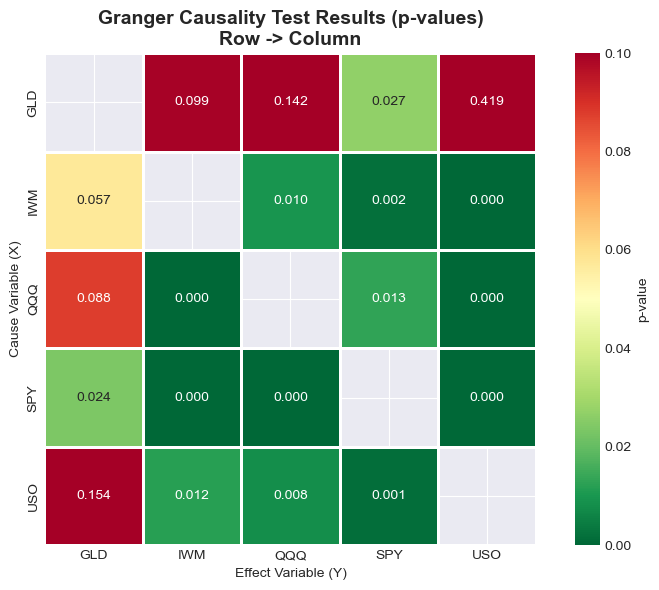


Interpretation: p-value < 0.05 implies X Granger-causes Y (significant at 5% level)


In [7]:
# Granger causality test
# To test whether past values of one time series X provide statistically significant information about future values of another Y.  

maxlag = min(12, optimal_lag)
granger_results = pd.DataFrame(index=var_returns.columns, columns=var_returns.columns, dtype=float)

for col1 in var_returns.columns:
    for col2 in var_returns.columns:
        if col1 != col2:
            # Test if col1 Granger-causes col2
            test_data = var_returns[[col2, col1]]
            gc_result = grangercausalitytests(test_data, maxlag=maxlag, verbose=False) # computes the test for all lags up to maxlag
            
            # Extract minimum p-value across all lags
            min_pval = min([gc_result[lag][0]['ssr_ftest'][1] for lag in range(1, maxlag+1)])
            granger_results.loc[col1, col2] = min_pval
        else:
            granger_results.loc[col1, col2] = np.nan

# Convert to float for proper display
granger_results = granger_results.astype(float)

# Visualize Granger causality p-values
plt.figure(figsize=(8, 6))
mask = np.eye(len(granger_results), dtype=bool) # creates an identity matrix with entries True(1) and False(0)
sns.heatmap(granger_results, annot=True, fmt='.3f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=0.1, square=True, linewidths=1, # mask is used to hide specific cells (where the mask is True)
            cbar_kws={'label': 'p-value'})
plt.title('Granger Causality Test Results (p-values)\nRow -> Column', 
          fontsize=14, fontweight='bold')
plt.xlabel('Effect Variable (Y)')
plt.ylabel('Cause Variable (X)')
plt.tight_layout()
plt.show()

print("\nInterpretation: p-value < 0.05 implies X Granger-causes Y (significant at 5% level)")

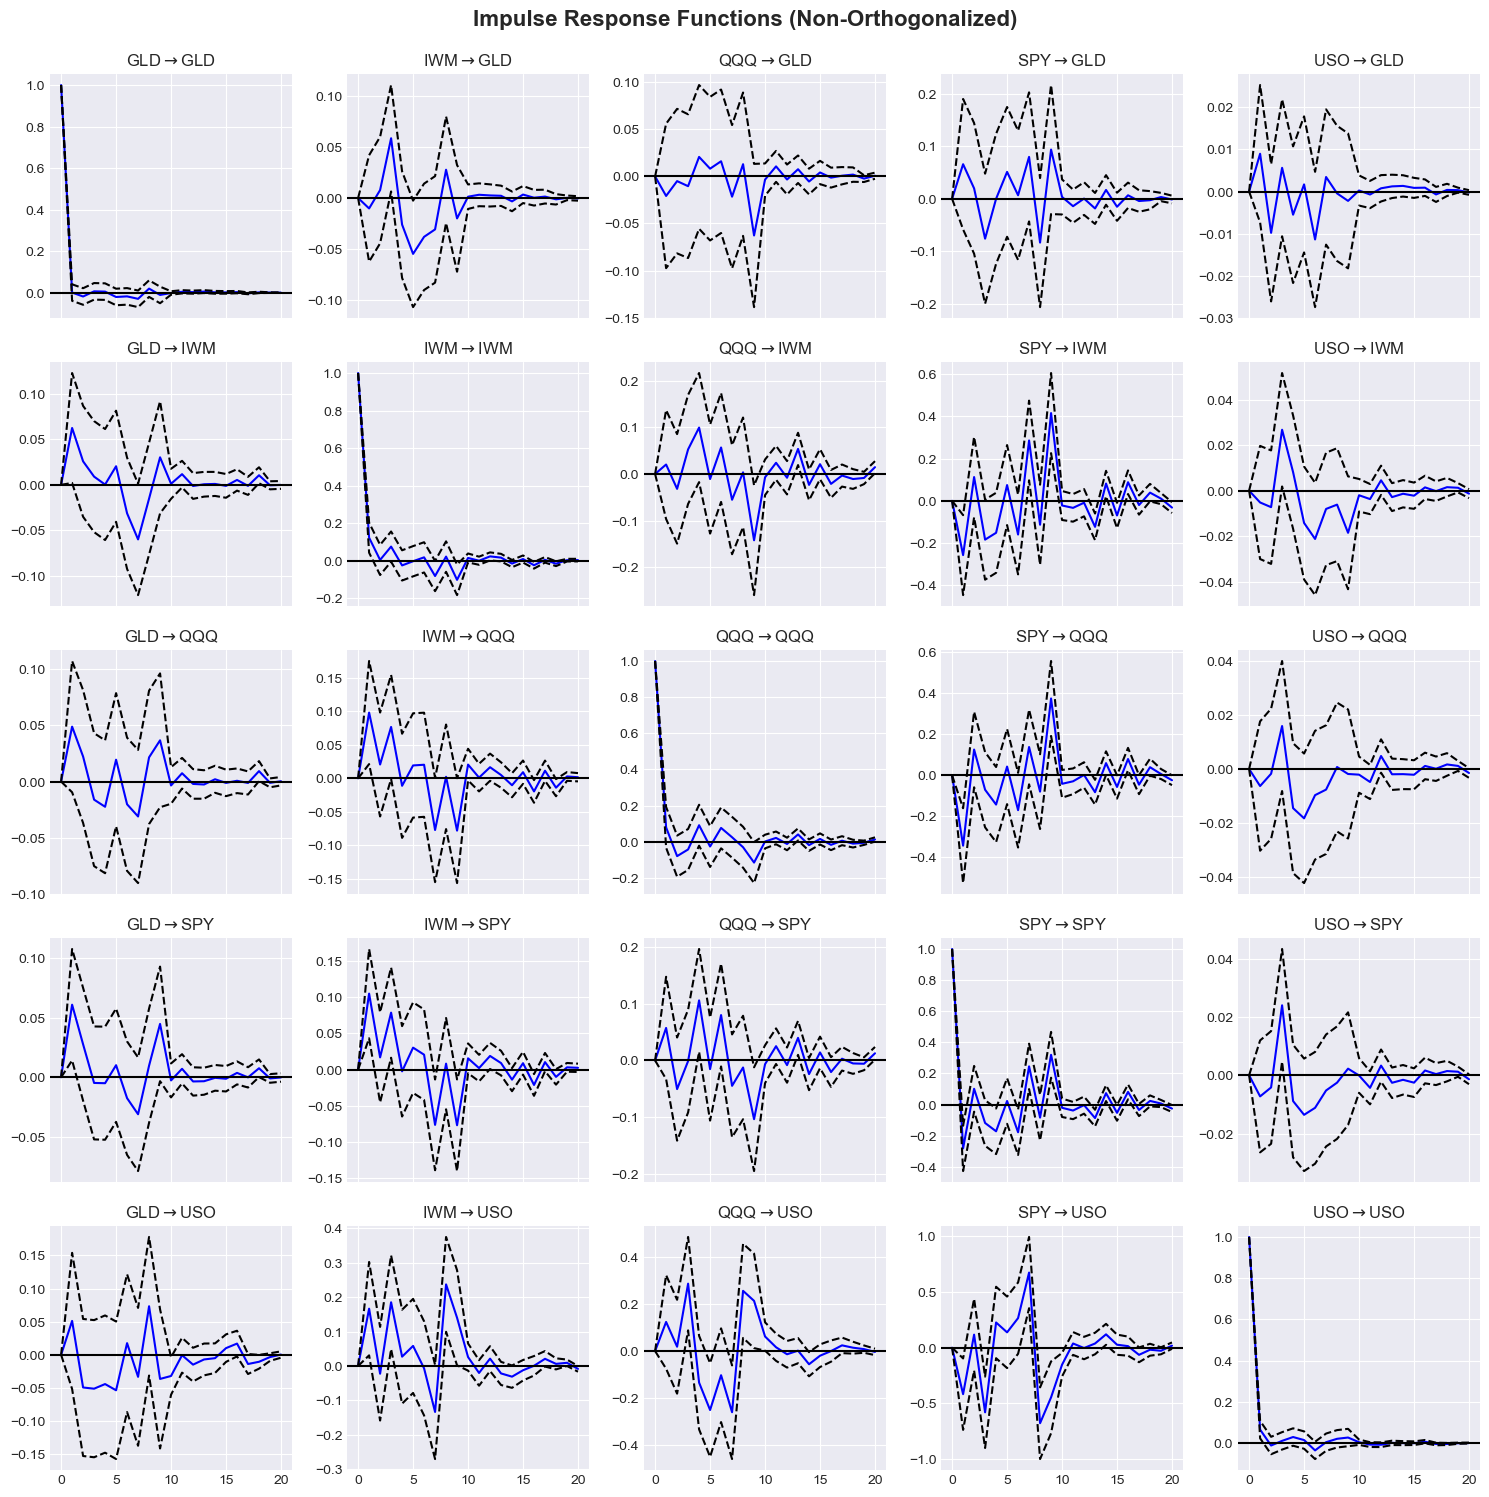

In [8]:
# Compute impulse response functions
irf = var_fit.irf(periods=20)

# Plot IRFs
fig = irf.plot(orth=False, figsize=(15, 15)) # orth: whether to use orthogonalized shocks (via Cholesky decomposition)
                                             # plot_stderr defaults to True; to display error bands
plt.suptitle('Impulse Response Functions (Non-Orthogonalized)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Plot orthogonalized IRFs (Cholesky decomposition)
#fig = irf.plot(orth=True, figsize=(16, 20)) 
#plt.suptitle('Impulse Response Functions (Orthogonalized - Cholesky)', fontsize=16, fontweight='bold', y=0.995) # Set the suptitle near the top (y=0.995)
#plt.tight_layout()
#plt.show()

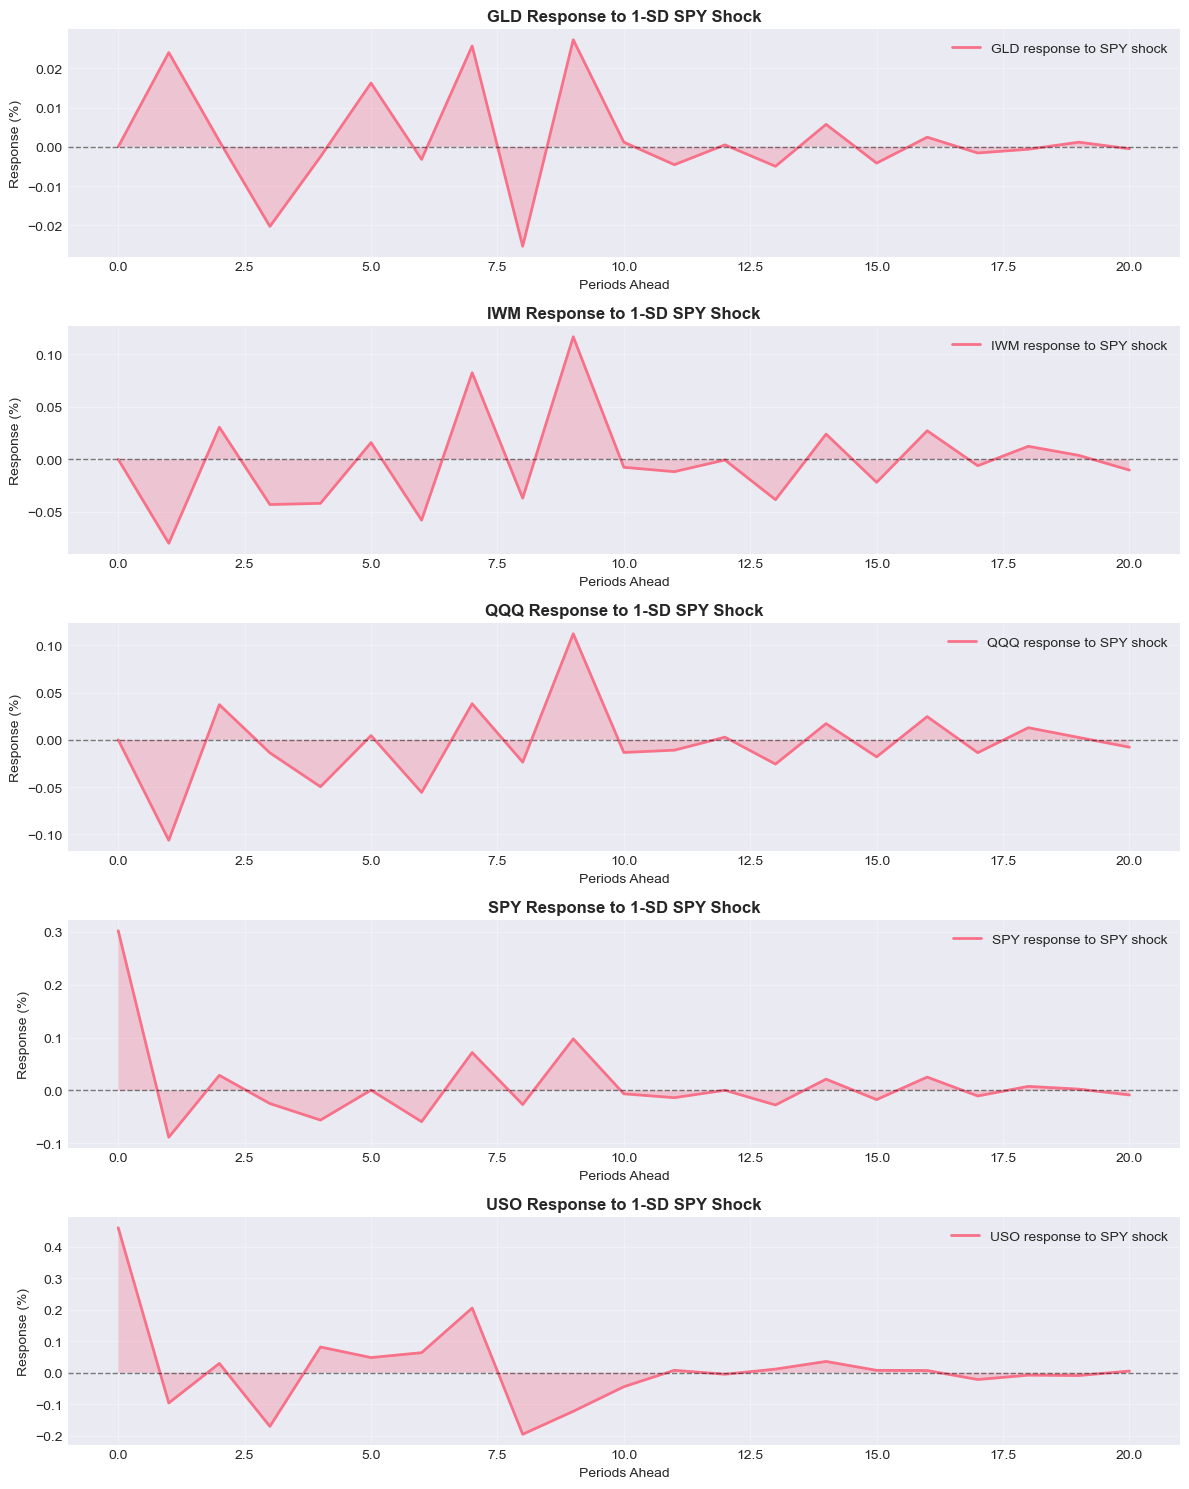


Cumulative Responses to 1-SD SPY Shock (after 10 days):
- GLD: 0.0432%
- IWM: -0.0143%
- QQQ: -0.0569%
- SPY: 0.2455%
- USO: 0.3043%


In [9]:
# On specific shock transmission: SPY shock → other markets

periods = 20
irf = var_fit.irf(periods=periods)

# Extract IRF data for SPY shocks
spy_shock_idx = list(var_returns.columns).index('SPY')
responses = irf.orth_irfs[:, :, spy_shock_idx] # orthogonalized impulse response functions (OIRFs) using Cholesky decomposition
# irf.orth_irfs returns an array, with dimensions (periods, num_variables, num_variables), where index [t, i, j] represents the effect of a shock in variable j on variable i at time t.
# It returns the effect of a one-standard-deviation innovation on variables over time. 
# This means the orthogonalized innovations are scaled to have a variance equal to one (or the shocks are scaled by the standard deviation), not that the function returns the standard deviation as an output value. 

fig, axes = plt.subplots(len(var_returns.columns), 1, figsize=(12, 15))

for i, col in enumerate(var_returns.columns):
    response = responses[:, i]
    
    axes[i].plot(response, linewidth=2, label=f'{col} response to SPY shock')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[i].fill_between(range(periods+1), 0, response, alpha=0.3)
    axes[i].set_title(f'{col} Response to 1-SD SPY Shock', fontweight='bold')
    axes[i].set_xlabel('Periods Ahead')
    axes[i].set_ylabel('Response (%)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Calculate cumulative responses
print("\nCumulative Responses to 1-SD SPY Shock (after 10 days):")
for i, col in enumerate(var_returns.columns):
    cumulative_response = responses[:10, i].sum()
    print(f"- {col}: {cumulative_response:.4f}%")

In [10]:
# Cointegration Analysis
# Two non-stationary series are cointegrated if a linear combination of them is stationary. This is crucial for pairs trading.

# Engle-Granger two-step method:
# Test if both series are I(1) (non-stationary in levels, stationary in first differences)
# Estimate the cointegrating relationship: y_t = \alpha + \beta x_t + \epsilon_t
# Test if residuals \epsilon_t are stationary (ADF test)

In [11]:
# Download pairs of stocks for cointegration analysis
print("Downloading pairs of related stocks...")

# Financial sector pairs
pairs = {
    'Banks': ['JPM', 'BAC'],
    'Tech': ['MSFT', 'GOOGL'],
    'Oil': ['XOM', 'CVX'],
    'Retail': ['WMT', 'TGT']
}

pair_data = {}
for sector, tickers in pairs.items():
    data = yf.download(tickers, start='2023-01-01', end='2025-12-31', progress=False, auto_adjust=False)
    pair_data[sector] = data['Adj Close'].dropna()
    print(f"- {sector}: {tickers[0]} vs {tickers[1]} - {len(pair_data[sector])} observations")

- Banks: JPM vs BAC - 751 observations
- Tech: MSFT vs GOOGL - 751 observations
- Oil: XOM vs CVX - 751 observations
- Retail: WMT vs TGT - 751 observations


In [12]:
# Test for cointegration using Engle-Granger method

cointegration_results = {}

for sector, data in pair_data.items():
    ticker1, ticker2 = data.columns[0], data.columns[1]
    series1 = data[ticker1]
    series2 = data[ticker2]
    
    print(f"\n{sector}: {ticker1} vs {ticker2}")
    print("-" * 50)
    
    # Step 1: Test for unit roots in levels
    adf1 = adfuller(series1, maxlag=20, regression='c')
    adf2 = adfuller(series2, maxlag=20, regression='c')
    
    print(f"\nStep 1: Unit Root Tests (Levels)")
    print(f"- {ticker1}: ADF = {adf1[0]:.4f}, p-value = {adf1[1]:.4f}")
    print(f"- {ticker2}: ADF = {adf2[0]:.4f}, p-value = {adf2[1]:.4f}")
    
    if adf1[1] > 0.05 and adf2[1] > 0.05:
        print("=> Both series are non-stationary (suitable for cointegration test)")
    
    # Step 2: Test for cointegration
    # Null Hypothesis (H₀): the two time series are not cointegrated (they do not share a common stochastic trend).
    # Alternative Hypothesis (H₁): the two time series are cointegrated (they move together in the long run).
    coint_stat, coint_pval, critical_values = coint(series1, series2)
    # coint_stat: the t-statistic of the unit-root test on the residuals of the regression
    # coint_pval: MacKinnon's approximate asymptotic p-value
    # critical_values: a dictionary of critical values for the test at the 1%, 5%, and 10% levels
    
    print(f"\nStep 2: Cointegration Test (Engle-Granger)")
    print(f"- Test statistic: {coint_stat:.4f}")
    print(f"- p-value: {coint_pval:.4f}")
    print(f"- Critical values:")
    for i, level in enumerate([0.1, 0.05, 0.01]):
        print(f"    {level*100:.0f}%: {critical_values[i]:.4f}")
    
    if coint_pval < 0.05:
        print(f"=> Series are COINTEGRATED at 5% significance level")
        cointegrated = True
    else:
        print(f"=> Series are NOT cointegrated at 5% significance level")
        cointegrated = False
    
    cointegration_results[sector] = {
        'tickers': [ticker1, ticker2],
        'statistic': coint_stat,
        'p-value': coint_pval,
        'cointegrated': cointegrated
    }


Banks: BAC vs JPM
--------------------------------------------------

Step 1: Unit Root Tests (Levels)
- BAC: ADF = -0.0967, p-value = 0.9498
- JPM: ADF = 0.1824, p-value = 0.9713
=> Both series are non-stationary (suitable for cointegration test)

Step 2: Cointegration Test (Engle-Granger)
- Test statistic: -2.7865
- p-value: 0.1700
- Critical values:
    10%: -3.9111
    5%: -3.3443
    1%: -3.0501
=> Series are NOT cointegrated at 5% significance level

Tech: GOOGL vs MSFT
--------------------------------------------------

Step 1: Unit Root Tests (Levels)
- GOOGL: ADF = 1.0668, p-value = 0.9949
- MSFT: ADF = -1.7761, p-value = 0.3924
=> Both series are non-stationary (suitable for cointegration test)

Step 2: Cointegration Test (Engle-Granger)
- Test statistic: -0.0118
- p-value: 0.9856
- Critical values:
    10%: -3.9111
    5%: -3.3443
    1%: -3.0501
=> Series are NOT cointegrated at 5% significance level

Oil: CVX vs XOM
--------------------------------------------------

Step

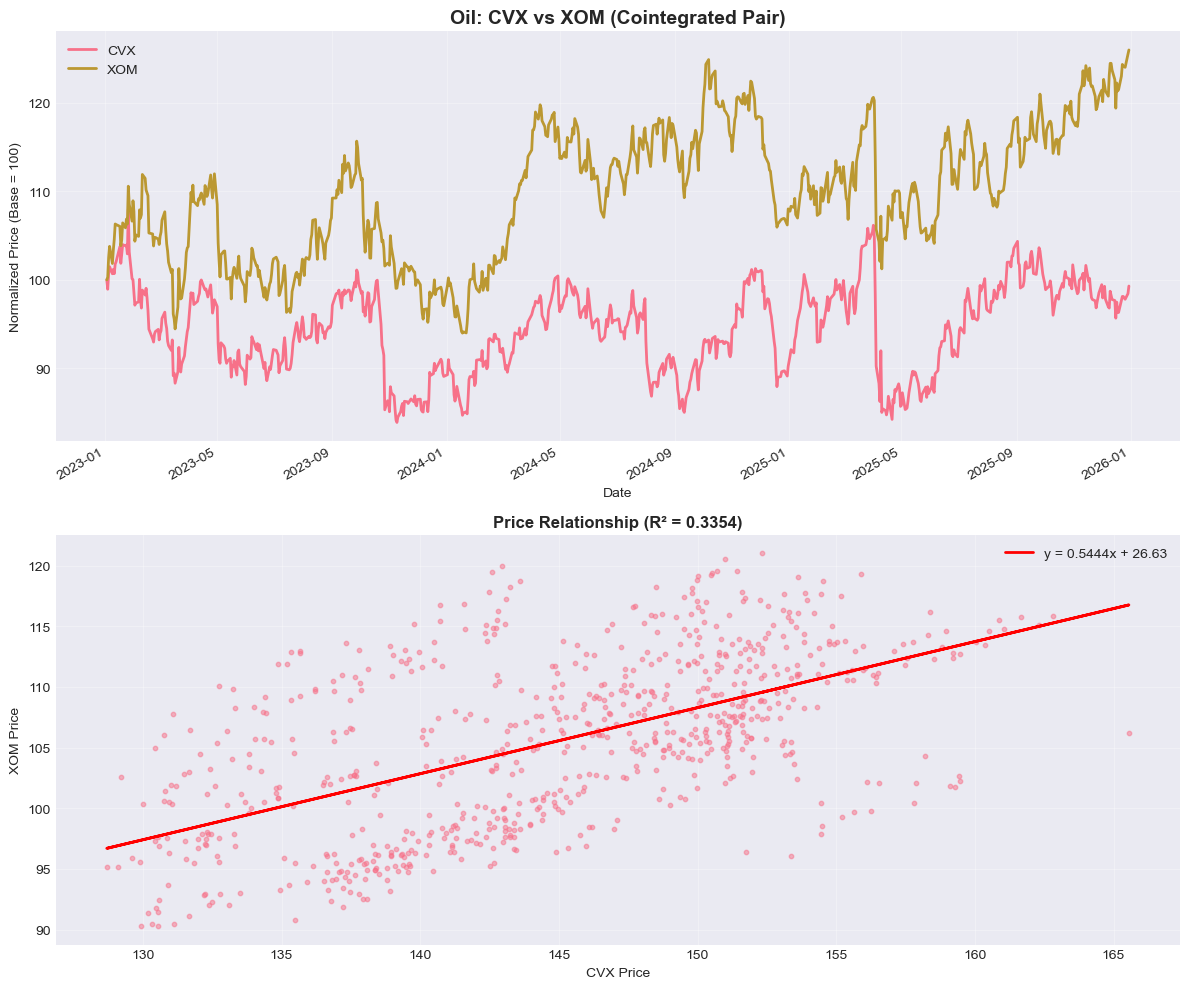

In [13]:
# Visualize price relationships for cointegrated pairs
for sector, result in cointegration_results.items():
    if result['cointegrated']:
        ticker1, ticker2 = result['tickers']
        data = pair_data[sector]
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot normalized prices
        norm_prices = data / data.iloc[0] * 100
        norm_prices.plot(ax=axes[0], linewidth=2)
        axes[0].set_title(f'{sector}: {ticker1} vs {ticker2} (Cointegrated Pair)', 
                         fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Normalized Price (Base = 100)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot scatter with regression line
        from scipy import stats as sp_stats
        slope, intercept, r_value, p_value, std_err = sp_stats.linregress(data[ticker1], data[ticker2])
        
        axes[1].scatter(data[ticker1], data[ticker2], alpha=0.5, s=10)
        axes[1].plot(data[ticker1], intercept + slope * data[ticker1], 
                    'r-', linewidth=2, label=f'y = {slope:.4f}x + {intercept:.2f}')
        axes[1].set_xlabel(f'{ticker1} Price')
        axes[1].set_ylabel(f'{ticker2} Price')
        axes[1].set_title(f'Price Relationship (R² = {r_value**2:.4f})', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [14]:
# Pairs Trading Strategy

# We implement a complete pairs trading strategy with:
# 1. Hedge ratio (beta) using OLS
# 2. Spread and z-score calculation
# 3. Trading signals based on spread deviation
# 4. Transaction costs and slippage
# 5. Performance metrics

# Select the most cointegrated pair for trading
best_pair_sector = min(cointegration_results.items(), 
                       key=lambda x: x[1]['p-value'] if x[1]['cointegrated'] else 1.0)
best_pair_sector = best_pair_sector[0] # returns sector name

print(f"Selected pair for trading: {best_pair_sector}")
print(f"- Tickers: {cointegration_results[best_pair_sector]['tickers']}")
print(f"- Cointegration p-value: {cointegration_results[best_pair_sector]['p-value']:.4f}")

# Get the data
trading_data = pair_data[best_pair_sector].copy()
ticker1, ticker2 = trading_data.columns[0], trading_data.columns[1]
price1 = trading_data[ticker1]
price2 = trading_data[ticker2]

Selected pair for trading: Oil
- Tickers: ['CVX', 'XOM']
- Cointegration p-value: 0.0198


In [15]:
# Step 1: Estimate hedge ratio using OLS regression
# We regress price2 on price1 to find the beta
from sklearn.linear_model import LinearRegression

# Use training period (first 70% of data)
train_size = int(len(trading_data) * 0.7)
train_data = trading_data.iloc[:train_size]
test_data = trading_data.iloc[train_size:]

print(f"\nData Split:")
print(f"- Training: {train_data.index[0].date()} to {train_data.index[-1].date()} ({len(train_data)} obs)")
print(f"- Testing:  {test_data.index[0].date()} to {test_data.index[-1].date()} ({len(test_data)} obs)")

# Estimate hedge ratio on training data
X_train = train_data[ticker1].values.reshape(-1, 1) # The training data (independent variables), which should be a 2D array or matrix
y_train = train_data[ticker2].values # The target values (dependent variable), typically a 1D array or similar

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

hedge_ratio = lr_model.coef_[0]
intercept = lr_model.intercept_

print(f"\nHedge Ratio Estimation (OLS): {ticker2} = {intercept:.4f} + {hedge_ratio:.4f} × {ticker1}")
print(f"=> Interpretation: Short ${hedge_ratio:.2f} of {ticker2} for every $1 long in {ticker1}")


Data Split:
- Training: 2023-01-03 to 2025-02-05 (525 obs)
- Testing:  2025-02-06 to 2025-12-30 (226 obs)

Hedge Ratio Estimation (OLS): XOM = 33.0482 + 0.4921 × CVX
=> Interpretation: Short $0.49 of XOM for every $1 long in CVX


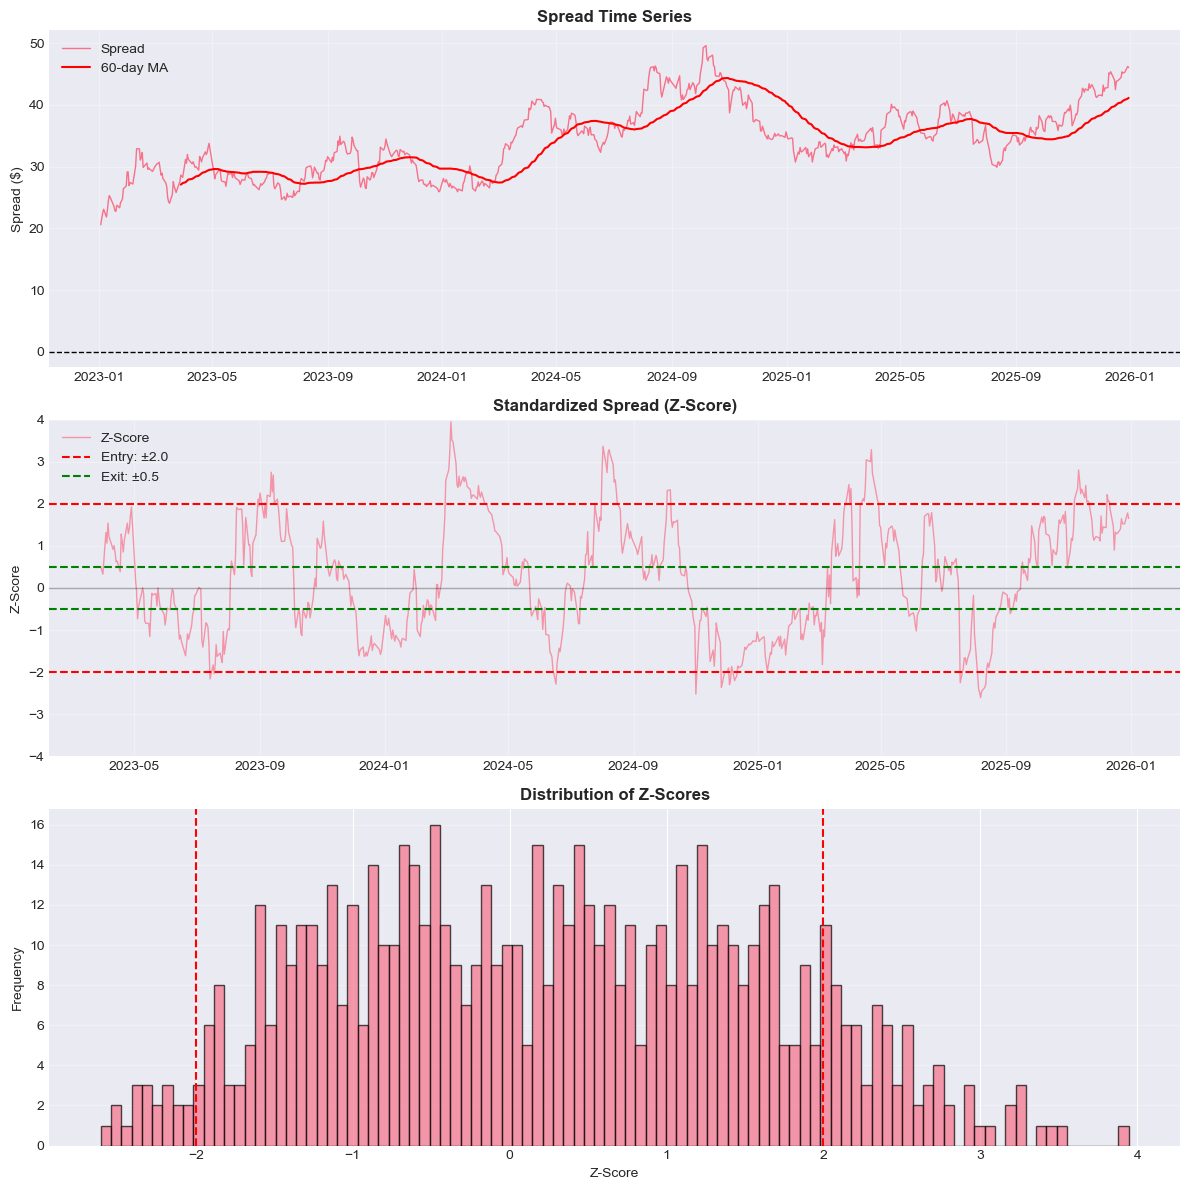


Spread Statistics (Full Period):
- Mean: 34.2047
- Std Dev: 5.7338
- Min: 20.5880
- Max: 49.5918


In [16]:
# Step 2: Construct the spread series
# Spread = price2 - hedge_ratio * price1

spread = price2 - hedge_ratio * price1 # alternative: spread between log prices has better statistical properties
spread_train = spread.iloc[:train_size]
spread_test = spread.iloc[train_size:]

# Calculate z-score of the spread (standardized spread)
# Use rolling window for adaptive mean and std
lookback_window = 60  # 60-day rolling window

spread_mean = spread.rolling(window=lookback_window).mean()
spread_std = spread.rolling(window=lookback_window).std()
z_score = (spread - spread_mean) / spread_std

# Visualize spread and z-score
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Raw spread
axes[0].plot(spread.index, spread, linewidth=1, label='Spread')
axes[0].plot(spread_mean.index, spread_mean, linewidth=1.5, 
            label=f'{lookback_window}-day MA', color='red')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
#axes[0].axvline(x=test_data.index[0], color='green', linestyle='--', linewidth=2, label='Test Period Start')
axes[0].set_title('Spread Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Spread ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Z-score with entry/exit thresholds
entry_threshold = 2.0
exit_threshold = 0.5

axes[1].plot(z_score.index, z_score, linewidth=1, label='Z-Score', alpha=0.7)
axes[1].axhline(y=entry_threshold, color='red', linestyle='--', 
               linewidth=1.5, label=f'Entry: ±{entry_threshold}')
axes[1].axhline(y=-entry_threshold, color='red', linestyle='--', linewidth=1.5)
axes[1].axhline(y=exit_threshold, color='green', linestyle='--', 
               linewidth=1.5, label=f'Exit: ±{exit_threshold}')
axes[1].axhline(y=-exit_threshold, color='green', linestyle='--', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
#axes[1].axvline(x=test_data.index[0], color='green', linestyle='--', linewidth=2, label='Test Period Start')
axes[1].set_title('Standardized Spread (Z-Score)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Z-Score')
axes[1].set_ylim([-4, 4])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Distribution of z-scores
axes[2].hist(z_score.dropna(), bins=100, alpha=0.7, edgecolor='black')
axes[2].axvline(x=entry_threshold, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline(x=-entry_threshold, color='red', linestyle='--', linewidth=1.5)
#axes[2].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[2].set_title('Distribution of Z-Scores', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Z-Score')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nSpread Statistics (Full Period):")
print(f"- Mean: {spread.mean():.4f}")
print(f"- Std Dev: {spread.std():.4f}")
print(f"- Min: {spread.min():.4f}")
print(f"- Max: {spread.max():.4f}")


Trading Signals (Test Period):
- Entry threshold: ±2.0 std devs
- Exit threshold: ±0.5 std devs
- Number of trades: 10
- Long positions: 27 days
- Short positions: 67 days
- Flat positions: 132 days


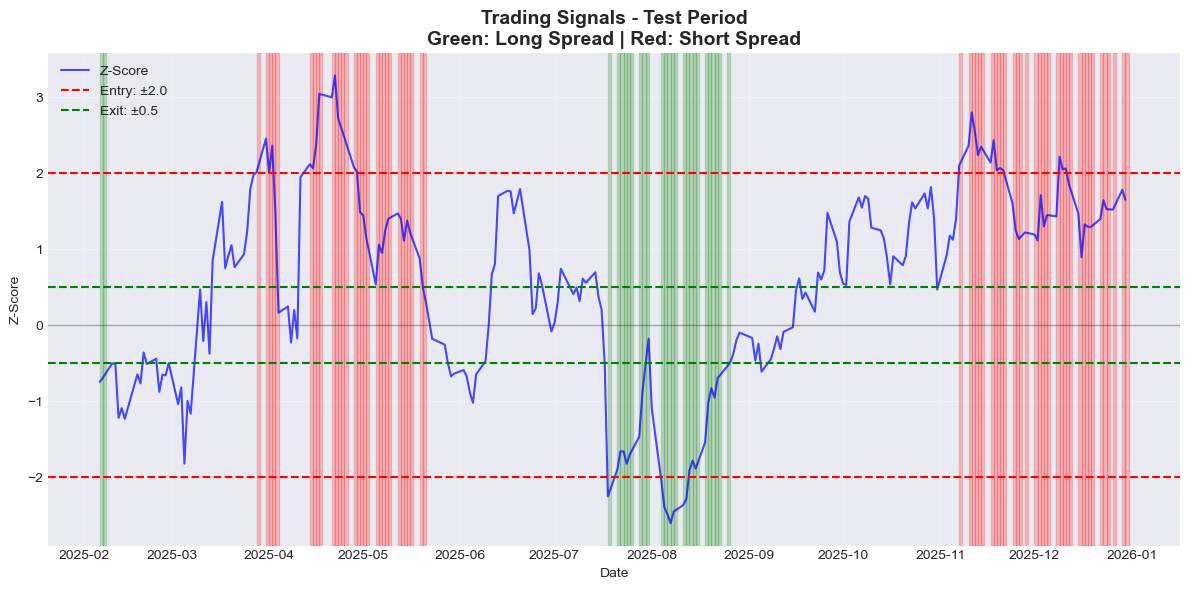

In [17]:
# Step 3: Generate trading signals
# Entry: |z-score| > entry_threshold
# Exit: |z-score| < exit_threshold
# Position (recall Spread = Price of stock2 - hedge_ratio * Price of stock1, where we regress stock2 on stock1): 
#  - Long spread (long stock2, short stock1) when z-score < -entry_threshold
#  - Short spread (short stock2, long stock1) when z-score > entry_threshold

def generate_signals(z_score, entry_threshold=2.0, exit_threshold=0.5):
    """
    Generate trading signals based on z-score
    Returns:
        signals: 1 (long spread), -1 (short spread), 0 (no position)
    """
    signals = pd.Series(0, index=z_score.index)
    position = 0 # Current position
    
    for i in range(1, len(z_score)):
        if pd.isna(z_score.iloc[i]):
            signals.iloc[i] = position
            continue
        
        z = z_score.iloc[i]
        
        # Entry signals
        if position == 0:
            if z < -entry_threshold:
                position = 1 # Long spread
            elif z > entry_threshold:
                position = -1 # Short spread
        
        # Exit signals
        elif position == 1: # Currently long spread
            if z > -exit_threshold:
                position = 0 # Close position
        
        elif position == -1: # Currently short spread
            if z < exit_threshold:
                position = 0 # Close position
        
        signals.iloc[i] = position
    
    return signals

# Generate signals for test period only
signals = generate_signals(z_score, entry_threshold=entry_threshold, exit_threshold=exit_threshold)
signals_test = signals.loc[test_data.index]

# Count trades
position_changes = signals_test.diff().abs()
num_trades = (position_changes > 0).sum()

print(f"\nTrading Signals (Test Period):")
print(f"- Entry threshold: ±{entry_threshold} std devs")
print(f"- Exit threshold: ±{exit_threshold} std devs")
print(f"- Number of trades: {num_trades}")
print(f"- Long positions: {(signals_test == 1).sum()} days")
print(f"- Short positions: {(signals_test == -1).sum()} days")
print(f"- Flat positions: {(signals_test == 0).sum()} days")


# Visualize signals on z-score chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot z-score for test period
z_score_test = z_score.loc[test_data.index]
ax.plot(z_score_test.index, z_score_test, linewidth=1.5, label='Z-Score', color='blue', alpha=0.7)

# Threshold lines
ax.axhline(y=entry_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Entry: ±{entry_threshold}')
ax.axhline(y=-entry_threshold, color='red', linestyle='--', linewidth=1.5)
ax.axhline(y=exit_threshold, color='green', linestyle='--', linewidth=1.5, label=f'Exit: ±{exit_threshold}')
ax.axhline(y=-exit_threshold, color='green', linestyle='--', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)

# Highlight positions
long_periods = signals_test[signals_test == 1]
short_periods = signals_test[signals_test == -1]

for idx in long_periods.index:
    ax.axvspan(idx, idx + pd.Timedelta(days=1), alpha=0.2, color='green')

for idx in short_periods.index:
    ax.axvspan(idx, idx + pd.Timedelta(days=1), alpha=0.2, color='red')

ax.set_title(f'Trading Signals - Test Period\nGreen: Long Spread | Red: Short Spread', 
            fontsize=14, fontweight='bold')
ax.set_ylabel('Z-Score')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

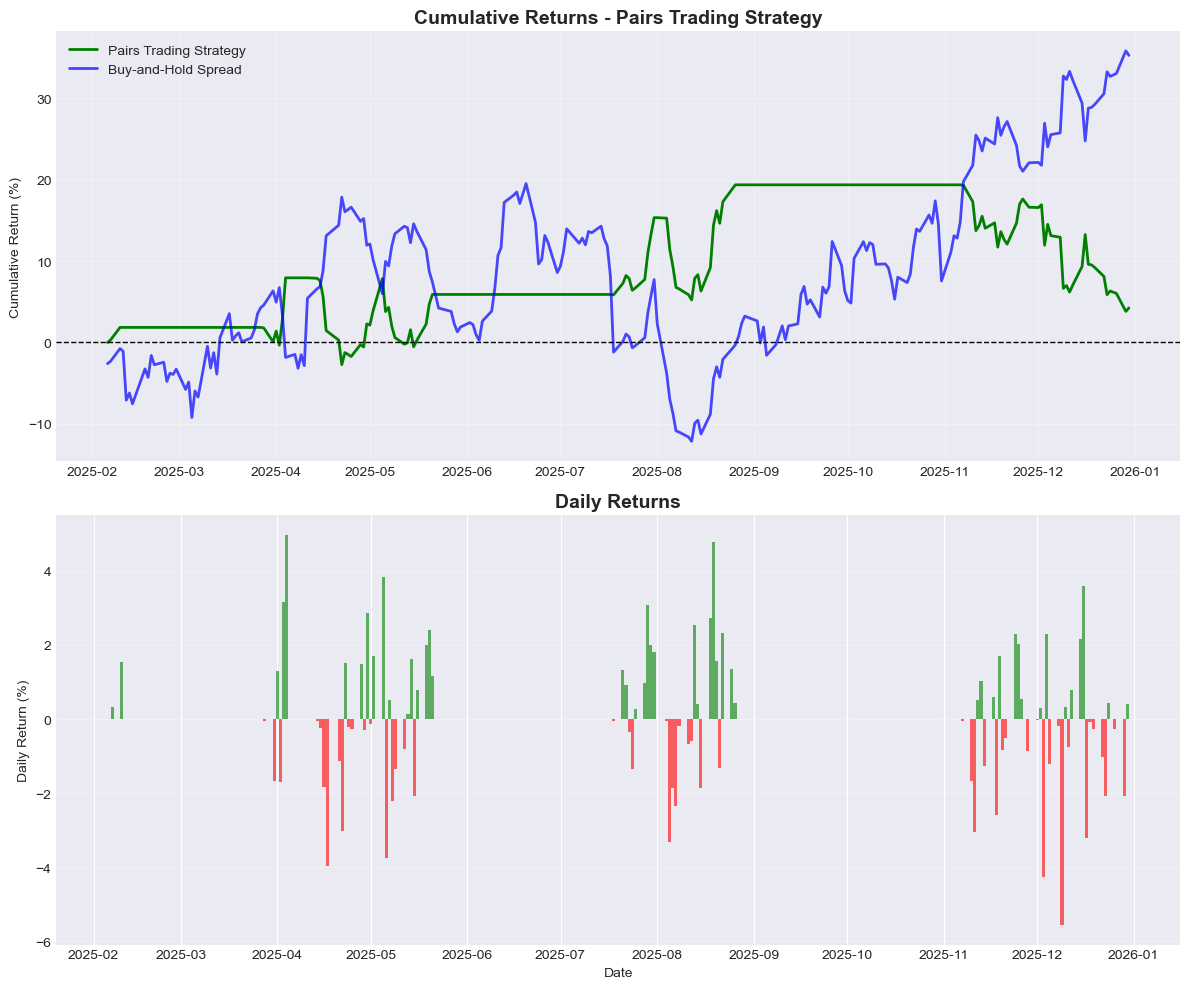

In [18]:
# Step 4: Calculate P&L with transaction costs
# Transaction costs include:
#  - Commission: 0.001% per trade (very low for institutional)
#  - Slippage: 0.05% per trade (market impact)
#  - Bid-ask spread: implicit in slippage

commission_rate = 0.00001  # 0.001%
slippage_rate = 0.0005     # 0.05%

# Calculate daily returns of the spread
spread_returns = spread.pct_change()
spread_returns_test = spread_returns.loc[test_data.index]

# Calculate strategy returns (position * spread_return)
# Use lagged signals to avoid look-ahead bias
lagged_signals = signals_test.shift(1).fillna(0)
strategy_returns = lagged_signals * spread_returns_test

# Apply transaction costs on position changes
position_changes = signals_test.diff().abs()
transaction_costs = position_changes * (commission_rate + slippage_rate)

# Net returns after costs
net_returns = strategy_returns - transaction_costs
net_returns = net_returns.fillna(0)

# Calculate cumulative returns
cumulative_returns = (1 + net_returns).cumprod()
cumulative_spread = (1 + spread_returns_test.fillna(0)).cumprod() # buy and hold

# Visualize P&L
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Cumulative returns
axes[0].plot(cumulative_returns.index, (cumulative_returns - 1) * 100, 
            linewidth=2, label='Pairs Trading Strategy', color='green')
axes[0].plot(cumulative_spread.index, (cumulative_spread - 1) * 100, 
            linewidth=2, label='Buy-and-Hold Spread', color='blue', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Cumulative Returns - Pairs Trading Strategy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Daily returns
axes[1].bar(net_returns.index, net_returns * 100, width=1, alpha=0.6, 
           color=['green' if x > 0 else 'red' for x in net_returns])
axes[1].set_title('Daily Returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [19]:
cumulative_spread

Date
2025-02-06    0.973970
2025-02-07    0.977057
2025-02-10    0.992479
2025-02-11    0.989241
2025-02-12    0.929125
                ...   
2025-12-23    1.332415
2025-12-24    1.326684
2025-12-26    1.330392
2025-12-29    1.358086
2025-12-30    1.352516
Length: 226, dtype: float64

In [20]:
# Step 5: Calculate performance metrics
def calculate_performance_metrics(returns, annual_factor=252):
    """
    Calculate comprehensive performance metrics for a return series
    """
    returns = returns.dropna()
    
    # Basic statistics
    total_return = (1 + returns).prod() - 1
    n_periods = len(returns)
    n_years = n_periods / annual_factor
    
    # Annualized return
    annualized_return = (1 + total_return) ** (1 / n_years) - 1
    
    # Volatility (annualized)
    volatility = returns.std() * np.sqrt(annual_factor)
    
    # Sharpe ratio (assuming 0% risk-free rate)
    sharpe_ratio = annualized_return / volatility if volatility != 0 else 0
    
    # Sortino ratio (downside deviation)
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(annual_factor)
    sortino_ratio = annualized_return / downside_std if downside_std != 0 else 0
    
    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Calmar ratio
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Win rate
    win_rate = (returns > 0).sum() / len(returns)
    
    # Profit factor
    gross_profit = returns[returns > 0].sum()
    gross_loss = abs(returns[returns < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf
    
    return {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Volatility (Ann.)': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Win Rate': win_rate,
        'Profit Factor': profit_factor,
        'Skewness': stats.skew(returns),
        'Kurtosis': stats.kurtosis(returns)
    }

# Calculate metrics for strategy and benchmark
strategy_metrics = calculate_performance_metrics(net_returns)
spread_metrics = calculate_performance_metrics(spread_returns_test.fillna(0))

# Display results
print("\nPerformance Metrics - Test Period")
print("-" * 70)

metrics_df = pd.DataFrame({
    'Pairs Trading Strategy': strategy_metrics,
    'Buy-and-Hold Spread': spread_metrics
})

print("\n", metrics_df.to_string())

# Additional trade statistics
print("\nTrade Statistics: ")
total_cost = transaction_costs.sum()
print(f"- Number of trades: {num_trades}")
print(f"- Total transaction costs: {total_cost*100:.4f}%")
print(f"- Average holding period: {(signals_test != 0).sum() / (num_trades/2 if num_trades > 0 else 1):.1f} days")
print(f"- Time in market: {(signals_test != 0).sum() / len(signals_test) * 100:.1f}%")


Performance Metrics - Test Period
----------------------------------------------------------------------

                    Pairs Trading Strategy  Buy-and-Hold Spread
Total Return                     0.042418             0.352516
Annualized Return                0.047412             0.400328
Volatility (Ann.)                0.203822             0.373278
Sharpe Ratio                     0.232615             1.072467
Sortino Ratio                    0.229382             1.644963
Max Drawdown                    -0.130216            -0.264791
Calmar Ratio                     0.364103             1.511864
Win Rate                         0.207965             0.548673
Profit Factor                    1.085092             1.196904
Skewness                        -0.108717            -0.086353
Kurtosis                         4.346677             1.199828

Trade Statistics: 
- Number of trades: 10
- Total transaction costs: 0.5100%
- Average holding period: 18.8 days
- Time in market: 41.6

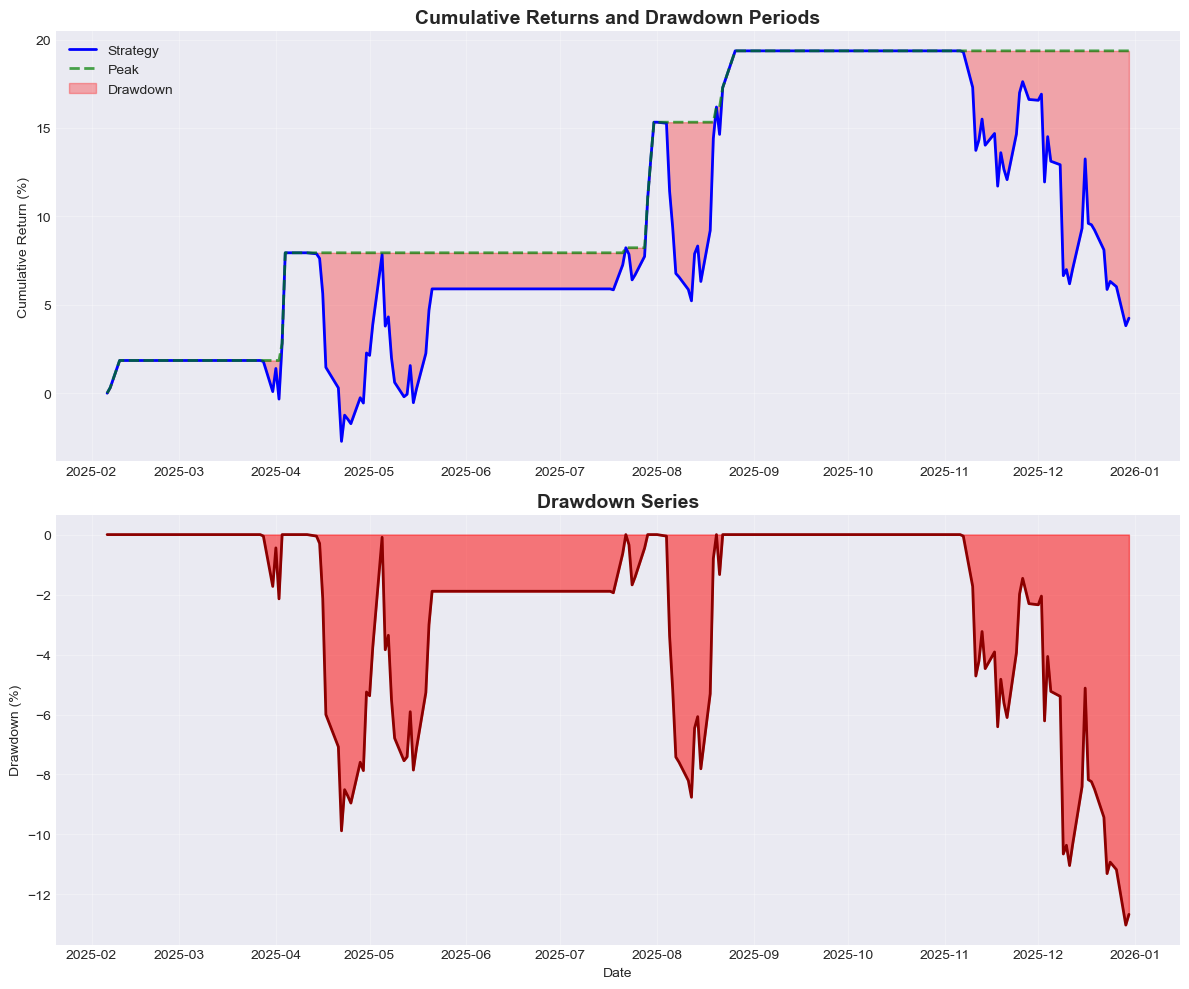


Maximum Drawdown: -13.02%
Occurred on: 2025-12-29


In [21]:
# Drawdown analysis
cumulative = (1 + net_returns).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Cumulative returns with drawdown periods
axes[0].plot(cumulative.index, (cumulative - 1) * 100, linewidth=2, label='Strategy', color='blue')
axes[0].plot(running_max.index, (running_max - 1) * 100, linewidth=2, 
            linestyle='--', label='Peak', color='green', alpha=0.7)
axes[0].fill_between(cumulative.index, (cumulative - 1) * 100, (running_max - 1) * 100, 
                     alpha=0.3, color='red', label='Drawdown')
axes[0].set_title('Cumulative Returns and Drawdown Periods', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown series
axes[1].fill_between(drawdown.index, drawdown * 100, 0, alpha=0.5, color='red')
axes[1].plot(drawdown.index, drawdown * 100, linewidth=2, color='darkred')
axes[1].set_title('Drawdown Series', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find largest drawdown period
max_dd_idx = drawdown.idxmin()
max_dd_value = drawdown.min()
print(f"\nMaximum Drawdown: {max_dd_value*100:.2f}%")
print(f"Occurred on: {max_dd_idx.date()}")

In [22]:
# Monte Carlo simulation for strategy robustness
# Test strategy with different entry/exit thresholds to evaluate performance consistency beyond a single historical backtest
print("\nParameter Sensitivity Analysis")
print("-" * 70)

entry_thresholds = [1.5, 2.0, 2.5]
exit_thresholds = [0.25, 0.5, 0.75]

sensitivity_results = []

for entry_th in entry_thresholds:
    for exit_th in exit_thresholds:
        # Generate signals with new thresholds
        signals_temp = generate_signals(z_score, entry_threshold=entry_th, exit_threshold=exit_th)
        signals_temp = signals_temp.loc[test_data.index]
        
        # Calculate returns
        lagged_signals_temp = signals_temp.shift(1).fillna(0)
        strategy_returns_temp = lagged_signals_temp * spread_returns_test
        
        position_changes_temp = signals_temp.diff().abs()
        transaction_costs_temp = position_changes_temp * (commission_rate + slippage_rate)
        
        net_returns_temp = strategy_returns_temp - transaction_costs_temp
        net_returns_temp = net_returns_temp.fillna(0)
        
        # Calculate metrics
        metrics_temp = calculate_performance_metrics(net_returns_temp)
        num_trades_temp = (position_changes_temp > 0).sum()
        
        sensitivity_results.append({
            'Entry Threshold': entry_th,
            'Exit Threshold': exit_th,
            'Sharpe Ratio': metrics_temp['Sharpe Ratio'],
            'Annualized Return': metrics_temp['Annualized Return'],
            'Max Drawdown': metrics_temp['Max Drawdown'],
            'Number of Trades': num_trades_temp
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df.to_string(index=False))

# Find optimal parameters
best_params = sensitivity_df.loc[sensitivity_df['Sharpe Ratio'].idxmax()]
print("\nOptimal Parameters (by Sharpe Ratio):")
print(f"- Entry Threshold: {best_params['Entry Threshold']}")
print(f"- Exit Threshold: {best_params['Exit Threshold']}")
print(f"- Sharpe Ratio: {best_params['Sharpe Ratio']:.4f}")


Parameter Sensitivity Analysis
----------------------------------------------------------------------
 Entry Threshold  Exit Threshold  Sharpe Ratio  Annualized Return  Max Drawdown  Number of Trades
             1.5            0.25      0.193761           0.055183     -0.242995                12
             1.5            0.50      1.016640           0.257384     -0.155017                16
             1.5            0.75      1.345059           0.318669     -0.130216                17
             2.0            0.25      0.404721           0.099644     -0.130216                10
             2.0            0.50      0.232615           0.047412     -0.130216                10
             2.0            0.75      0.026251           0.004987     -0.130216                 9
             2.5            0.25      0.700827           0.152909     -0.117337                 6
             2.5            0.50      0.451460           0.075939     -0.117337                 5
             2.

In [23]:
# Principal Component Analysis (PCA)
# PCA identifies orthogonal factors (principal components) that explain the maximum variance in the data. This is crucial for:
# - Understanding common risk drivers
# - Reducing dimensionality in large portfolios
# - Building statistical factor models

In [24]:
# Download stock data for a diversified portfolio
print("Downloading stock data...")

tickers = {
    'Tech': ['AAPL', 'MSFT', 'GOOGL', 'NVDA'],
    'Finance': ['JPM', 'BAC', 'GS', 'WFC'],
    'Consumer': ['AMZN', 'WMT', 'HD', 'MCD'],
    'Healthcare': ['JNJ', 'UNH', 'PFE', 'ABBV'],
    'Energy': ['XOM', 'CVX', 'COP', 'SLB']
}

all_tickers = [ticker for sector in tickers.values() for ticker in sector]

# Download data
stock_data = yf.download(all_tickers, start='2016-01-01', end='2025-12-31', progress=False, auto_adjust=False)
prices = stock_data['Adj Close'].dropna()

# Calculate log returns
returns = np.log(prices / prices.shift(1)).dropna() * 100

print(f"\nSample period: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Number of observations: {len(returns)}")
print(f"Number of stocks: {len(all_tickers)}")
print(f"\nSectors and stocks:")
for sector, stocks in tickers.items():
    print(f"- {sector}: {', '.join(stocks)}")


Sample period: 2016-01-05 to 2025-12-30
Number of observations: 2512
Number of stocks: 20

Sectors and stocks:
- Tech: AAPL, MSFT, GOOGL, NVDA
- Finance: JPM, BAC, GS, WFC
- Consumer: AMZN, WMT, HD, MCD
- Healthcare: JNJ, UNH, PFE, ABBV
- Energy: XOM, CVX, COP, SLB


In [25]:
# Perform PCA on the return dataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\nPrincipal Component Analysis")
print("-" * 70)

# Standardize returns (important for PCA)
# This is to standardize data by calculating the mean and standard deviation of a dataset and then applying the transformation (mean subtraction and division by standard deviation)
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# Fit PCA
n_components = 10  # Extract first 10 components
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(returns_scaled)

# Convert to DataFrame
pc_df = pd.DataFrame(
    principal_components,
    index=returns.index,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print(f"Number of original features: {returns.shape[1]}")
print(f"Number of principal components: {n_components}")
print(f"\nExplained variance ratio by component:")
for i, var_ratio in enumerate(pca.explained_variance_ratio_):
    print(f"- PC{i+1}: {var_ratio*100:.2f}%")

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"\nCumulative explained variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"- First {i+1} PCs: {cum_var*100:.2f}%")


Principal Component Analysis
----------------------------------------------------------------------
Number of original features: 20
Number of principal components: 10

Explained variance ratio by component:
- PC1: 42.33%
- PC2: 12.04%
- PC3: 8.04%
- PC4: 5.93%
- PC5: 4.31%
- PC6: 3.73%
- PC7: 3.12%
- PC8: 2.92%
- PC9: 2.52%
- PC10: 2.28%

Cumulative explained variance:
- First 1 PCs: 42.33%
- First 2 PCs: 54.37%
- First 3 PCs: 62.41%
- First 4 PCs: 68.35%
- First 5 PCs: 72.66%
- First 6 PCs: 76.39%
- First 7 PCs: 79.50%
- First 8 PCs: 82.42%
- First 9 PCs: 84.94%
- First 10 PCs: 87.22%


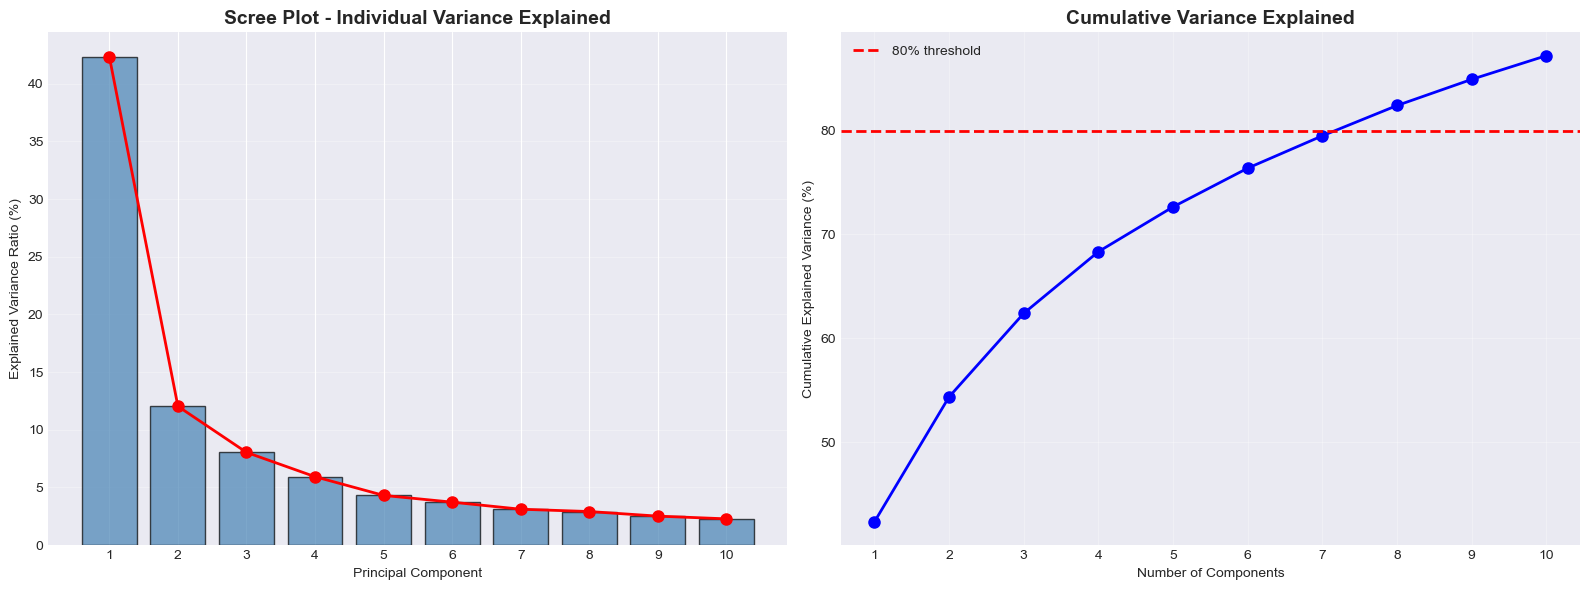


Number of components needed for 80% variance: 8
Dimension reduction: 20 → 8 (40.0%)


In [26]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, n_components+1), pca.explained_variance_ratio_ * 100, 
           alpha=0.7, color='steelblue', edgecolor='black')
axes[0].plot(range(1, n_components+1), pca.explained_variance_ratio_ * 100, 
            'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio (%)')
axes[0].set_title('Scree Plot - Individual Variance Explained', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, n_components+1))
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative explained variance
axes[1].plot(range(1, n_components+1), cumulative_variance * 100, 
            'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, 
               label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, n_components+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"\nNumber of components needed for 80% variance: {n_components_80}")
print(f"Dimension reduction: {returns.shape[1]} → {n_components_80} ({n_components_80/returns.shape[1]*100:.1f}%)")


Factor Loadings (Top 5 stocks by absolute loading):
----------------------------------------------------------------------

PC1 (explains 42.33% variance):
  JPM   :  0.2823
  BAC   :  0.2798
  GS    :  0.2793
  WFC   :  0.2615
  CVX   :  0.2564

PC2 (explains 12.04% variance):
  AMZN  :  0.3514
  MSFT  :  0.3369
  XOM   : -0.3261
  SLB   : -0.3174
  COP   : -0.3113

PC3 (explains 8.04% variance):
  JNJ   :  0.4819
  PFE   :  0.4339
  ABBV  :  0.3769
  NVDA  : -0.2771
  UNH   :  0.2721


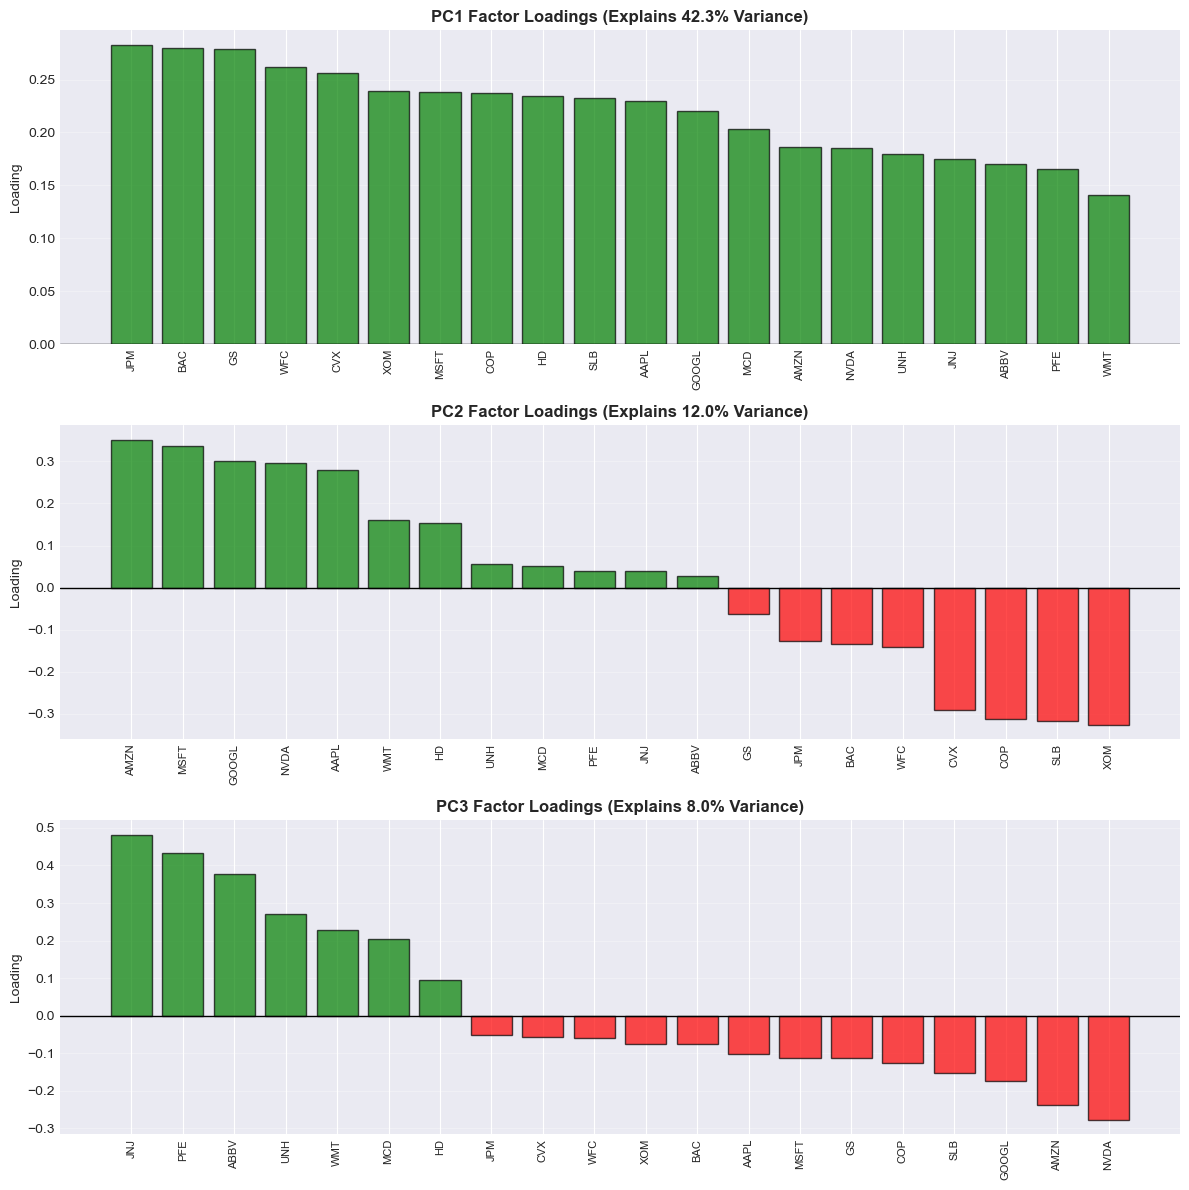

In [27]:
# Analyze factor loadings (component weights)
loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("\nFactor Loadings (Top 5 stocks by absolute loading):")
print("-" * 70)

for i in range(min(3, n_components)):  # Show first 3 PCs
    pc_name = f'PC{i+1}'
    top_loadings = loadings[pc_name].abs().nlargest(5)
    
    print(f"\n{pc_name} (explains {pca.explained_variance_ratio_[i]*100:.2f}% variance):")
    for stock, loading_val in top_loadings.items():
        actual_loading = loadings.loc[stock, pc_name]
        print(f"  {stock:6s}: {actual_loading:7.4f}") # 6s: left-aligned as a string with a minimum width of 6 characters
                                                      # 7.4f: a float with a total width of 7 characters (including the decimal point and digits) and exactly 4 digits after the decimal point

# Visualize loadings for first 3 PCs
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i in range(3):
    pc_name = f'PC{i+1}'
    loadings_sorted = loadings[pc_name].sort_values(ascending=False)
    
    colors = ['green' if x > 0 else 'red' for x in loadings_sorted]
    axes[i].bar(range(len(loadings_sorted)), loadings_sorted, 
               color=colors, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{pc_name} Factor Loadings (Explains {pca.explained_variance_ratio_[i]*100:.1f}% Variance)',
                     fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Loading')
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].set_xticks(range(len(loadings_sorted)))
    axes[i].set_xticklabels(loadings_sorted.index, rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

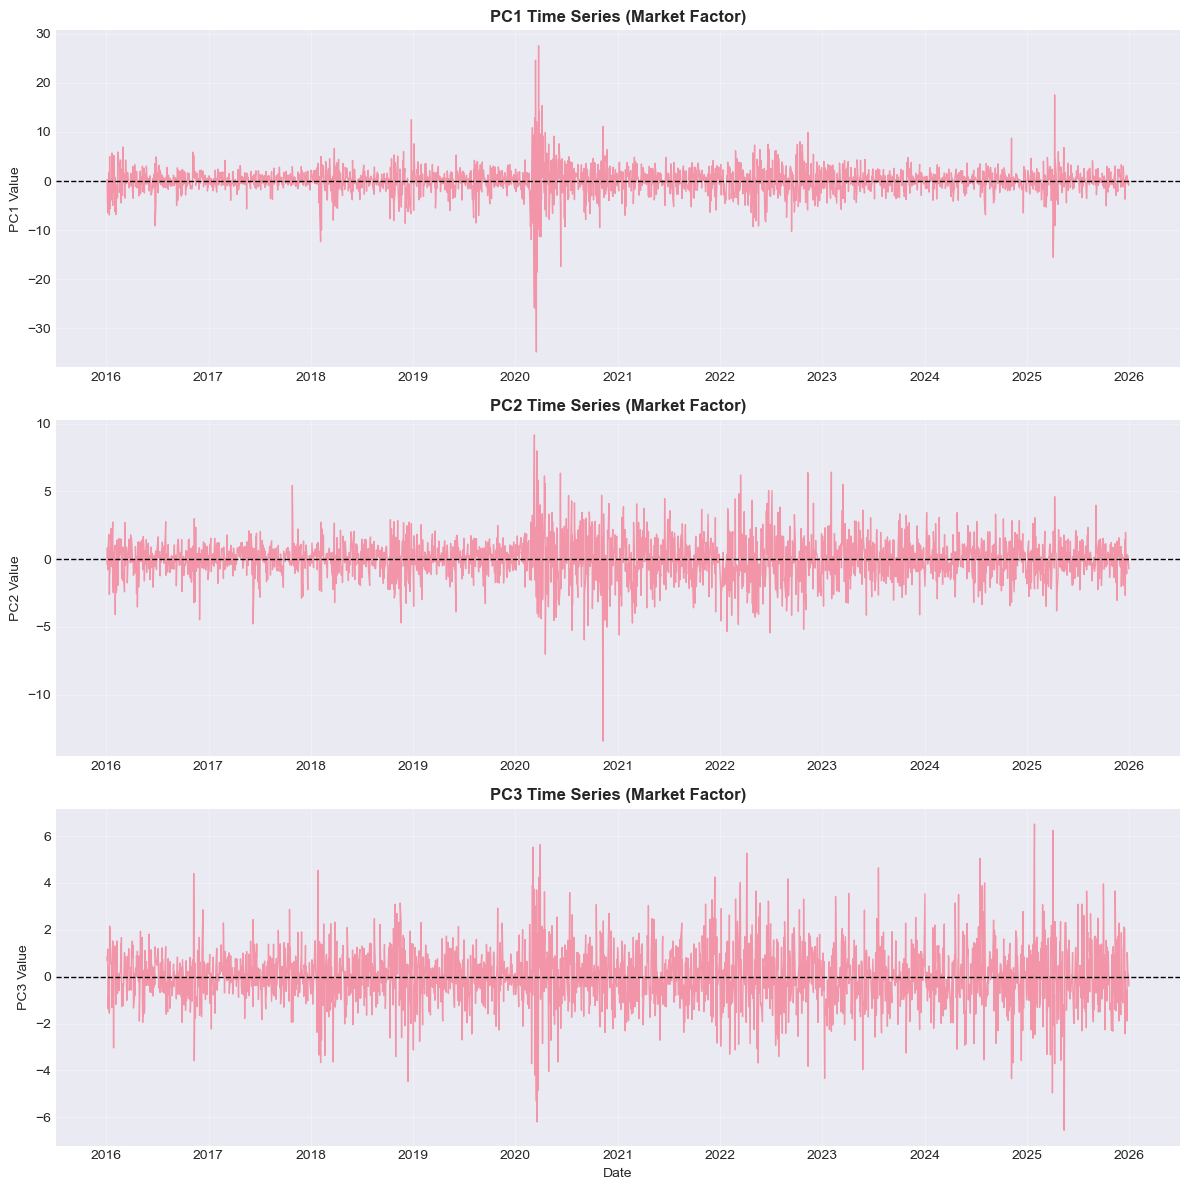


Interpretation:
- PC1: Market factor - common movement across all stocks
- PC2-PC3: Sector or style factors - capturing sector-specific risks


In [28]:
# Visualize principal component time series
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i in range(3):
    pc_name = f'PC{i+1}'
    axes[i].plot(pc_df.index, pc_df[pc_name], linewidth=1, alpha=0.7)
    axes[i].set_title(f'{pc_name} Time Series (Market Factor)', 
                     fontsize=12, fontweight='bold')
    axes[i].set_ylabel(f'{pc_name} Value')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Interpretation: PC1 typically represents "market factor"
print("\nInterpretation:")
print("- PC1: Market factor - common movement across all stocks")
print("- PC2-PC3: Sector or style factors - capturing sector-specific risks")